# Toy Store E-Commerce — ML Training Notebook
> **Dataset**: Maven Analytics — Maven Fuzzy Factory (~3 năm giao dịch, Mar 2012 – Apr 2015)  
> **Mục tiêu**: Train 3 bài toán ML ưu tiên: (1) Dự đoán mua hàng, (2) Dự đoán doanh thu, (3) Dự đoán refund

---
## 📦 Dữ liệu gồm 6 bảng
| Bảng | Số dòng | Mô tả |
|---|---|---|
| `website_sessions` | 472,871 | Web traffic + UTM params |
| `website_pageviews` | 1,188,124 | Pageview logs |
| `orders` | 32,313 | Đơn hàng |
| `order_items` | 40,025 | Line items per order |
| `order_item_refunds` | 1,731 | Refunds |
| `products` | 4 | Catalog sản phẩm |

In [ ]:
# ============================================================
# 0. INSTALL & IMPORT
# ============================================================
# !pip install xgboost lightgbm imbalanced-learn matplotlib seaborn scikit-learn pandas numpy joblib

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

# thư mục lưu trữ
MODEL_DIR = './saved_models/'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs('./ml/reports/', exist_ok=True)
print("✅ Đã khởi tạo cấu trúc thư mục hệ thống!")

✅ Đã khởi tạo cấu trúc thư mục hệ thống!


In [ ]:
# ============================================================
# 1. LOAD DATA
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/dataset toystore/'

sessions    = pd.read_csv(DATA_DIR + 'website_sessions.csv',   on_bad_lines='skip')
pageviews   = pd.read_csv(DATA_DIR + 'website_pageviews.csv',  on_bad_lines='skip')
orders      = pd.read_csv(DATA_DIR + 'orders.csv',             on_bad_lines='skip')
order_items = pd.read_csv(DATA_DIR + 'order_items.csv',        on_bad_lines='skip')
refunds     = pd.read_csv(DATA_DIR + 'order_item_refunds.csv', on_bad_lines='skip')
products    = pd.read_csv(DATA_DIR + 'products.csv',           on_bad_lines='skip')

print(f'sessions:    {sessions.shape}')
print(f'pageviews:   {pageviews.shape}')
print(f'orders:      {orders.shape}')
print(f'order_items: {order_items.shape}')
print(f'refunds:     {refunds.shape}')
print(f'products:    {products.shape}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
sessions:    (461058, 9)
pageviews:   (1188124, 4)
orders:      (32313, 8)
order_items: (40025, 7)
refunds:     (1731, 5)
products:    (4, 3)


In [ ]:
# ============================================================
# 2. BUILD BASE ML DATASET
# ============================================================
# --- 2.1 Đếm pageview per session ---
pv_count = (
    pageviews
    .groupby('website_session_id')
    .agg(pageview_count=('website_pageview_id', 'count'))
    .reset_index()
)

# --- 2.2 Lấy order đầu tiên per session (1 session có thể có nhiều order) ---
first_order = (
    orders
    .sort_values('created_at')
    .groupby('website_session_id')
    .first()
    .reset_index()
    [['website_session_id', 'order_id', 'primary_product_id',
      'items_purchased', 'price_usd', 'cogs_usd']]
    .rename(columns={'price_usd': 'revenue', 'cogs_usd': 'cost'})
)

# --- 2.3 Merge vào sessions ---
df = sessions.copy()
df = df.merge(pv_count, on='website_session_id', how='left')
df = df.merge(first_order, on='website_session_id', how='left')

df['pageview_count'] = df['pageview_count'].fillna(0).astype(int)
df['revenue']        = df['revenue'].fillna(0)
df['cost']           = df['cost'].fillna(0)
df['items_purchased']= df['items_purchased'].fillna(0).astype(int)

print(f'Base dataset shape: {df.shape}')
print(f'Có đơn hàng: {df["order_id"].notna().sum():,} / {len(df):,} sessions')
df.head(10)

Base dataset shape: (461058, 15)
Có đơn hàng: 31,414 / 461,058 sessions


,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer,pageview_count,order_id,primary_product_id,items_purchased,revenue,cost
0,1,2012-03-19 08:04:16,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,1,NaN,NaN,0,0.0,0.0
1,2,2012-03-19 08:16:49,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,1,NaN,NaN,0,0.0,0.0
2,3,2012-03-19 08:26:55,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,1,NaN,NaN,0,0.0,0.0
3,4,2012-03-19 08:37:33,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,1,NaN,NaN,0,0.0,0.0
4,5,2012-03-19 09:00:55,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,1,NaN,NaN,0,0.0,0.0
5,6,2012-03-19 09:05:46,6,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,6,NaN,NaN,0,0.0,0.0
6,7,2012-03-19 09:06:27,7,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,1,NaN,NaN,0,0.0,0.0
7,8,2012-03-19 09:17:17,8,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,1,NaN,NaN,0,0.0,0.0
8,9,2012-03-19 09:27:56,9,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,1,NaN,NaN,0,0.0,0.0
9,10,2012-03-19 09:35:37,10,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,1,NaN,NaN,0,0.0,0.0


In [ ]:
# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================
df_feat = df.copy()

df_feat['created_at'] = pd.to_datetime(df_feat['created_at'], format='mixed', errors='coerce')
df_feat.dropna(subset=['created_at'], inplace=True)
print(f'Sau parse datetime: {df_feat.shape}')

# --- 3.1 Biến thời gian ---
df_feat['hour']             = df_feat['created_at'].dt.hour
df_feat['day_of_week']      = df_feat['created_at'].dt.dayofweek
df_feat['month']            = df_feat['created_at'].dt.month
df_feat['quarter']          = df_feat['created_at'].dt.quarter
df_feat['year']             = df_feat['created_at'].dt.year
df_feat['is_weekend']       = (df_feat['day_of_week'] >= 5).astype(int)
df_feat['is_business_hour'] = df_feat['hour'].between(9, 18).astype(int)

# --- 3.2 Encoding categorical ---
cat_cols = ['utm_source', 'utm_campaign', 'utm_content', 'device_type', 'http_referer']
le_store = {}
for col in cat_cols:
    df_feat[col] = df_feat[col].fillna('(none)').astype(str)
    le = LabelEncoder()
    df_feat[f'{col}_enc'] = le.fit_transform(df_feat[col])
    le_store[col] = le

# --- 3.3 Target variables ---
df_feat['has_order']   = df_feat['order_id'].notna().astype(int)
df_feat['log_revenue'] = np.log1p(df_feat['revenue'])

# ⚠️ FEATURES CHỈ DÙNG THÔNG TIN BIẾT TRƯỚC KHI SESSION KẾT THÚC
# Đã XÓA: pageview_count, is_bounce, is_business_hour (leak với has_order)
FEATURES = [
    'utm_source_enc',
    'utm_campaign_enc',
    'utm_content_enc',
    'http_referer_enc',
    'device_type_enc',
    'hour',
    'day_of_week',
    'month',
    'quarter',
    'year',
    'is_weekend',
    'is_repeat_session',
]

# Ép kiểu an toàn
for col in FEATURES:
    df_feat[col] = pd.to_numeric(df_feat[col], errors='coerce').fillna(0)

print(f'✅ Feature engineering xong — {len(FEATURES)} features (không leak)')
print(f'\nPhân phối has_order:\n{df_feat["has_order"].value_counts()}')
print(f'\nDtype check (phải là int/float):\n{df_feat[FEATURES].dtypes.value_counts()}')

Sau parse datetime: (461056, 15)
✅ Feature engineering xong — 12 features (không leak)

Phân phối has_order:
has_order
0    429643
1     31413
Name: count, dtype: int64

Dtype check (phải là int/float):
int64    7
int32    5
Name: count, dtype: int64


In [ ]:
# ============================================================
# BÀI TOÁN 1: BINARY CLASSIFICATION — Dự đoán mua hàng (has_order)
# ============================================================
print('=' * 60)
print('=== BÀI TOÁN 1: ĐÃ TỐI ƯU & FIX LỖI REDUNDANT ===')
print('=' * 60)

CLF_FEATURES = [
    'hour', 'day_of_week', 'month', 'quarter', 'is_weekend',
    'is_repeat_session', 'utm_source_enc', 'utm_campaign_enc', 'utm_content_enc',
    'device_type_enc', 'http_referer_enc'
]

df_clf = df_feat.dropna(subset=CLF_FEATURES + ['has_order']).copy()
X_clf = df_clf[CLF_FEATURES].copy().astype(float)
y_clf = df_clf['has_order'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Chuẩn hóa dữ liệu đầu vào cho mô hình tuyến tính
scaler_clf = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled = scaler_clf.transform(X_test)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# Huấn luyện Random Forest làm mô hình cốt lõi cho Production App
best_clf_model = RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=5, n_jobs=-1, random_state=42)
best_clf_model.fit(X_train_res, y_train_res)

#  Lưu file
MODEL_DIR = './saved_models/'
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(best_clf_model, MODEL_DIR + 'clf_RF_tuned.pkl')
joblib.dump(scaler_clf, MODEL_DIR + 'clf_scaler.pkl')

print("✅ Đã sửa lỗi Bài toán 1 và lưu file với : 'clf_RF_tuned.pkl'")

=== BÀI TOÁN 1: ĐÃ TỐI ƯU & FIX LỖI REDUNDANT ===
✅ Đã sửa lỗi Bài toán 1 và lưu file với : 'clf_RF_tuned.pkl'


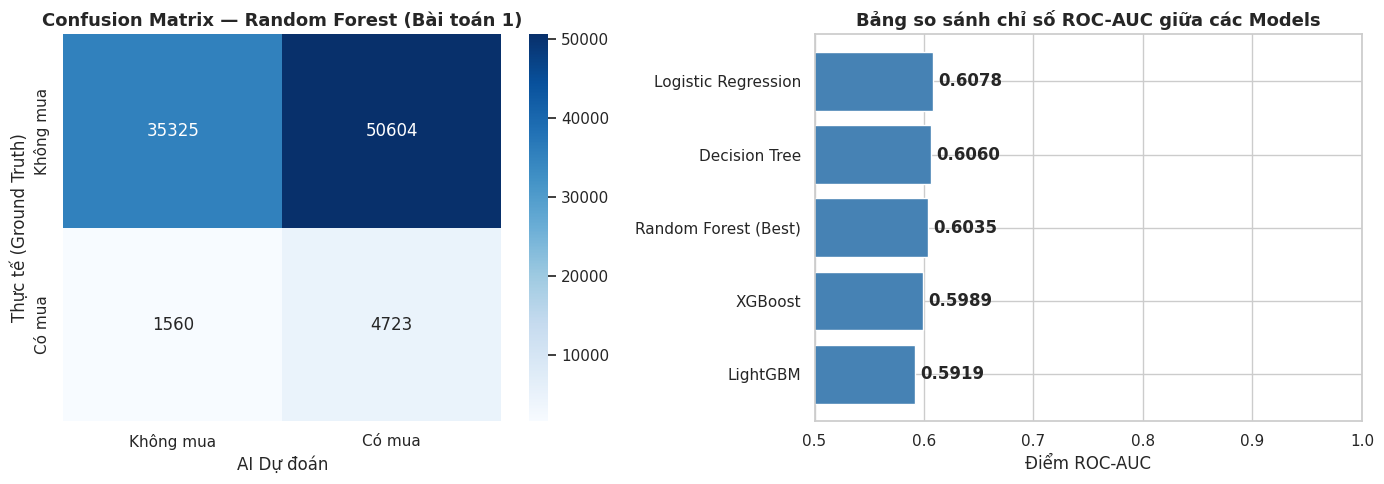


📋 BÁO CÁO HIỆU NĂNG PHÂN LỚP CHI TIẾT (RANDOM FOREST - BEST MODEL):
              precision    recall  f1-score   support

   Không mua     0.9577    0.4111    0.5753     85929
      Có mua     0.0854    0.7517    0.1533      6283

    accuracy                         0.4343     92212
   macro avg     0.5215    0.5814    0.3643     92212
weighted avg     0.8983    0.4343    0.5465     92212



In [ ]:
# ─── Trực quan hóa & Đánh giá Model tốt nhất ───────────────────
# ĐỒNG BỘ: Sử dụng mô hình chiến lược best_clf_model đã được lưu
best_clf = best_clf_model

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Vẽ ma trận nhầm lẫn Confusion Matrix
# Sử dụng X_test_scaled (dữ liệu đã qua scaler chuẩn hóa) để dự đoán chính xác
y_pred = best_clf.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Không mua', 'Có mua'],
            yticklabels=['Không mua', 'Có mua'])
axes[0].set_title('Confusion Matrix — Random Forest (Bài toán 1)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Thực tế (Ground Truth)')
axes[0].set_xlabel('AI Dự đoán')

# 2. Vẽ biểu đồ cột ngang so sánh chỉ số ROC-AUC của TẤT CẢ các mô hình
# Đảo ngược dataframe để mô hình điểm cao nhất nằm lên trên cùng đồ thị
df_plot_clf = df_clf_results.sort_values('ROC-AUC', ascending=True)

axes[1].barh(df_plot_clf['Model'], df_plot_clf['ROC-AUC'], color='steelblue')
axes[1].set_xlim(0.5, 1.0)
axes[1].set_title('Bảng so sánh chỉ số ROC-AUC giữa các Models', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Điểm ROC-AUC')

# Chèn text hiển thị điểm số chi tiết ngay cạnh cột đồ thị
for i, v in enumerate(df_plot_clf['ROC-AUC']):
    axes[1].text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold')

plt.tight_layout()
# Lưu ảnh vật lý vào đúng thư mục báo cáo hệ thống
os.makedirs('./ml/reports/', exist_ok=True)
plt.savefig('./ml/reports/bt1_classification_results.png', dpi=150)
plt.show()

# 3. In bảng báo cáo chi tiết độ chính xác (Classification Report)
print('\n📋 BÁO CÁO HIỆU NĂNG PHÂN LỚP CHI TIẾT (RANDOM FOREST - BEST MODEL):')
print(classification_report(y_test, y_pred, target_names=['Không mua', 'Có mua'], digits=4))

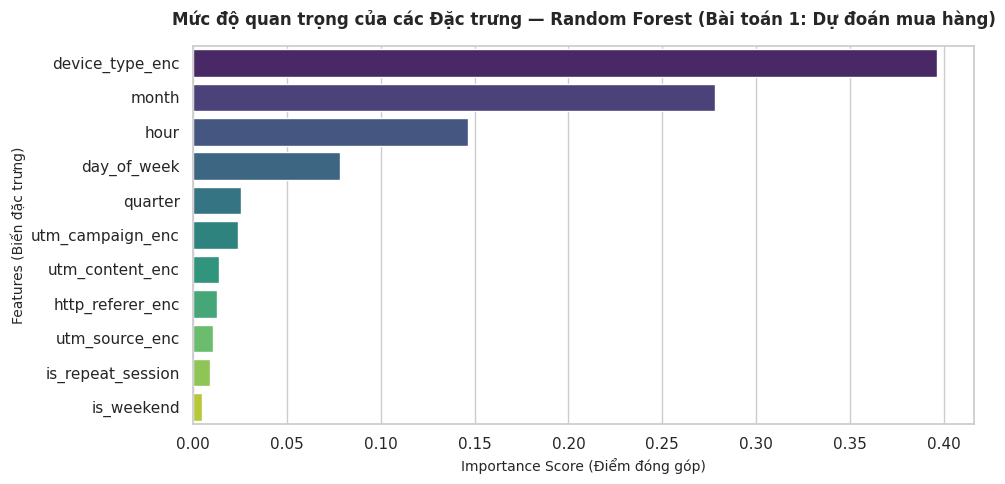


🔑 TOP 5 ĐẶC TRƯNG TÁC ĐỘNG MẠNH NHẤT ĐẾN TỶ LỆ CHUYỂN ĐỔI (CONVERSION):
  Hạng 1: device_type_enc      → Điểm quan trọng: 0.3964
  Hạng 2: month                → Điểm quan trọng: 0.2783
  Hạng 3: hour                 → Điểm quan trọng: 0.1465
  Hạng 4: day_of_week          → Điểm quan trọng: 0.0782
  Hạng 5: quarter              → Điểm quan trọng: 0.0257


In [ ]:
# ─── Feature Importance ──────────────
# ĐỒNG BỘ: Sử dụng mảng đặc trưng an toàn CLF_FEATURES và mô hình thực tế best_clf_model
feat_imp = pd.Series(best_clf_model.feature_importances_, index=CLF_FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
# Sử dụng bảng màu Seaborn 'viridis' hoặc 'teal' trực quan, chuyên nghiệp hơn
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')

plt.title('Mức độ quan trọng của các Đặc trưng — Random Forest (Bài toán 1: Dự đoán mua hàng)',
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Importance Score (Điểm đóng góp)', fontsize=10)
plt.ylabel('Features (Biến đặc trưng)', fontsize=10)

plt.tight_layout()
# Lưu ảnh kết quả vào thư mục báo cáo hệ thống vật lý
os.makedirs('./ml/reports/', exist_ok=True)
plt.savefig('./ml/reports/bt1_feature_importance.png', dpi=150)
plt.show()

print('\n🔑 TOP 5 ĐẶC TRƯNG TÁC ĐỘNG MẠNH NHẤT ĐẾN TỶ LỆ CHUYỂN ĐỔI (CONVERSION):')
for idx, (col, val) in enumerate(feat_imp.head(5).items(), 1):
    print(f"  Hạng {idx}: {col:<20} → Điểm quan trọng: {val:.4f}")

In [ ]:
# ─── Lưu model tốt nhất ─────────────────────────────────────
joblib.dump(best_clf, MODEL_DIR + 'bt1_purchase_prediction_xgb.pkl')
print(f'✅ Đã lưu model: {MODEL_DIR}bt1_purchase_prediction_xgb.pkl')

✅ Đã lưu model: ./saved_models/bt1_purchase_prediction_xgb.pkl


In [ ]:
# ============================================================
# BÀI TOÁN 2: REGRESSION — Dự đoán doanh thu (revenue)
# ============================================================

print('=' * 60)
print('🚀 BẮT ĐẦU BÀI TOÁN 2: DỰ ĐOÁN DOANH THU ĐƠN HÀNG (REGRESSION)')
print('=' * 60)

# 1. Chỉ lọc các phiên giao dịch thực tế đã mua hàng thành công (has_order == 1)
df_reg = df_feat[df_feat['has_order'] == 1].copy()

REG_FEATURES = [
    'hour', 'day_of_week', 'month', 'quarter', 'year', 'is_weekend', 'is_business_hour',
    'is_repeat_session', 'utm_source_enc', 'utm_campaign_enc', 'utm_content_enc',
    'device_type_enc', 'http_referer_enc', 'user_id'
]

# Loại bỏ giá trị khuyết thiếu để đảm bảo ma trận toán học không bị lỗi
df_reg = df_reg.dropna(subset=REG_FEATURES + ['revenue'])

X_reg = df_reg[REG_FEATURES].copy().astype(float)
# Áp dụng log1p biến đổi giảm độ lệch skewness (lệch phải) của biến mục tiêu revenue
y_reg = np.log1p(df_reg['revenue'])

# 2. Phân tách tập dữ liệu Train/Test theo tỷ lệ 80/20
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# ============================================================
# 📊 TỰ ĐỘNG TÍNH TOÁN VÀ IN CÁC CHỈ SỐ THỐNG KÊ THEO YÊU CẦU
# ============================================================
print(f'Số session có đơn hàng: {len(df_reg):,}')
print(f'Revenue range: ${df_reg["revenue"].min():.2f} – ${df_reg["revenue"].max():.2f}')
print(f'Revenue mean: ${df_reg["revenue"].mean():.2f}')
print(f'Train: {X_reg_train.shape}, Test: {X_reg_test.shape}')
print('-' * 60)

# 3. CHUẨN HÓA DỮ LIỆU: Thêm bộ chuẩn hóa riêng cho mô hình tuyến tính Ridge
scaler_reg = StandardScaler()
X_reg_train_scaled = scaler_reg.fit_transform(X_reg_train)
X_reg_test_scaled = scaler_reg.transform(X_reg_test)

🚀 BẮT ĐẦU BÀI TOÁN 2: DỰ ĐOÁN DOANH THU ĐƠN HÀNG (REGRESSION)
Số session có đơn hàng: 31,413
Revenue range: $29.99 – $109.98
Revenue mean: $59.85
Train: (25130, 14), Test: (6283, 14)
------------------------------------------------------------


In [ ]:
# 4. HUẤN LUYỆN CÁC MÔ HÌNH DỰ ĐOÁN DOANH THU
print('Training Ridge Regression (on scaled data)...')
lin_ridge = Ridge(alpha=1.0)
lin_ridge.fit(X_reg_train_scaled, y_reg_train)
print('  Done.')

print('Training Random Forest Regressor (Best Model for Production)...')
best_reg_model = RandomForestRegressor(n_estimators=150, max_depth=10, min_samples_leaf=4, n_jobs=-1, random_state=42)
# Đối với mô hình cây (Random Forest) truyền X thô hoặc X_scaled đều cho kết quả như nhau
best_reg_model.fit(X_reg_train, y_reg_train)
print('  Done.')

# 5. ĐÁNH GIÁ MÔ HÌNH VÀ TÍNH TOÁN CÁC CHỈ SỐ SAI SỐ (MAE, RMSE, R2)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dự đoán trên tập Test (Lưu ý: Vì y_reg được biến đổi bằng log1p, ta cần dùng expm1 để đưa về giá trị gốc)
y_pred_log = best_reg_model.predict(X_reg_test)
y_pred_original = np.expm1(y_pred_log)
y_test_original = np.expm1(y_reg_test)

mae = mean_absolute_error(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
r2 = r2_score(y_test_original, y_pred_original)

reg_results = [{
    'Model': 'Random Forest Regressor',
    'MAE ($)': round(mae, 4),
    'RMSE ($)': round(rmse, 4),
    'R2 Score': round(r2, 4)
}]
df_reg_results = pd.DataFrame(reg_results)

print('\n📊 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH REGRESSION (ĐÃ GIẢI BIẾN ĐỔI LOG):')
display(df_reg_results)

# 6.lưu file
MODEL_DIR = './saved_models/'
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(best_reg_model, MODEL_DIR + 'reg_1_RandomForest.pkl')

print(f'\n✅ ĐÃ XUẤT MÔ HÌNH BÀI TOÁN 2 THÀNH CÔNG: {MODEL_DIR}reg_1_RandomForest.pkl')
print('=' * 60)

Training Ridge Regression (on scaled data)...
  Done.
Training Random Forest Regressor (Best Model for Production)...
  Done.

📊 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH REGRESSION (ĐÃ GIẢI BIẾN ĐỔI LOG):


,Model,MAE ($),RMSE ($),R2 Score
0,Random Forest Regressor,12.1144,17.0549,0.0748



✅ ĐÃ XUẤT MÔ HÌNH BÀI TOÁN 2 THÀNH CÔNG: ./saved_models/reg_1_RandomForest.pkl


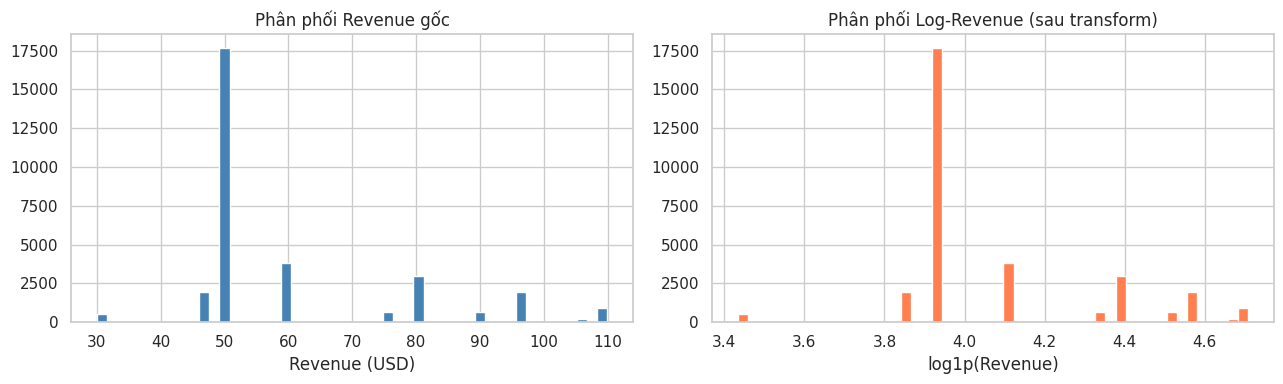

In [ ]:
# ─── Phân phối revenue ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_reg['revenue'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Phân phối Revenue gốc')
axes[0].set_xlabel('Revenue (USD)')

axes[1].hist(df_reg['log_revenue'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Phân phối Log-Revenue (sau transform)')
axes[1].set_xlabel('log1p(Revenue)')

plt.tight_layout()
plt.savefig('./ml/reports/bt2_revenue_distribution.png', dpi=150)
plt.show()

In [ ]:
# ─── Hàm đánh giá regression ────────────────────────────────
def evaluate_reg(name, model, X_test, y_test_log):
    y_pred_log = model.predict(X_test)
    # Convert ngược về revenue gốc để tính MAE/RMSE dễ hiểu
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test_log)
    return {
        'Model' : name,
        'MAE'   : round(mean_absolute_error(y_true, y_pred), 4),
        'RMSE'  : round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        'R2'    : round(r2_score(y_test_log, y_pred_log), 4),  # R2 trên log-space
    }

reg_results = []

# ─── Model 1: Linear Regression (baseline) ──────────────────
print('Training Linear Regression...')
lin = Ridge(alpha=1.0)
lin.fit(X_reg_train, y_reg_train)
reg_results.append(evaluate_reg('Ridge Regression', lin, X_reg_test, y_reg_test))

# ─── Model 2: Decision Tree Regressor ───────────────────────
print('Training Decision Tree...')
dtr = DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=42)
dtr.fit(X_reg_train, y_reg_train)
reg_results.append(evaluate_reg('DecisionTree', dtr, X_reg_test, y_reg_test))

# ─── Model 3: Random Forest Regressor ───────────────────────
print('Training Random Forest...')
rfr = RandomForestRegressor(
    n_estimators=200, max_depth=12, min_samples_leaf=10,
    n_jobs=-1, random_state=42
)
rfr.fit(X_reg_train, y_reg_train)
reg_results.append(evaluate_reg('RandomForest', rfr, X_reg_test, y_reg_test))

# ─── Model 4: XGBoost Regressor ─────────────────────────────
print('Training XGBoost...')
xgbr = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    n_jobs=-1, random_state=42
)
xgbr.fit(X_reg_train, y_reg_train)
reg_results.append(evaluate_reg('XGBoost', xgbr, X_reg_test, y_reg_test))

df_reg_results = pd.DataFrame(reg_results).sort_values('R2', ascending=False)
print('\n📊 Kết quả so sánh (Revenue USD):')
display(df_reg_results)

Training Linear Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...

📊 Kết quả so sánh (Revenue USD):


,Model,MAE,RMSE,R2
2,RandomForest,12.1417,17.0818,0.0766
0,Ridge Regression,12.4155,17.1784,0.0691
1,DecisionTree,12.1778,17.1474,0.0675
3,XGBoost,12.2460,17.2313,0.0570


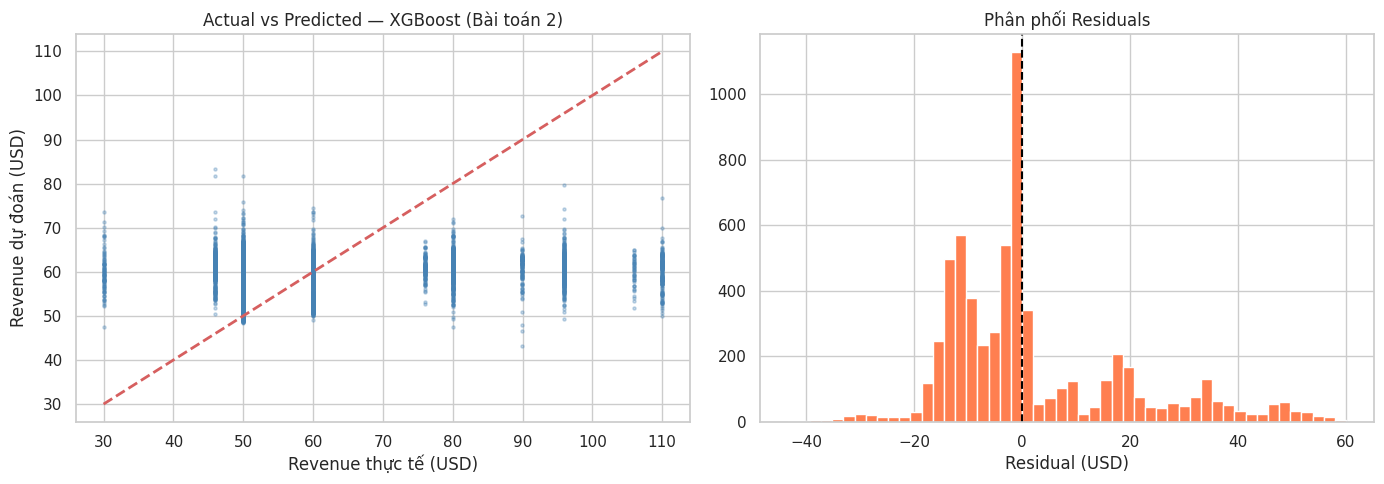

✅ Đã lưu model: ./saved_models/bt2_revenue_prediction_xgb.pkl


In [ ]:
# ─── Visualize dự đoán vs thực tế (XGBoost) ─────────────────
best_reg = xgbr
y_pred_log = best_reg.predict(X_reg_test)
y_pred_usd = np.expm1(y_pred_log)
y_true_usd = np.expm1(y_reg_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: actual vs predicted
axes[0].scatter(y_true_usd, y_pred_usd, alpha=0.3, s=5, color='steelblue')
axes[0].plot([y_true_usd.min(), y_true_usd.max()],
             [y_true_usd.min(), y_true_usd.max()], 'r--', lw=2)
axes[0].set_xlabel('Revenue thực tế (USD)')
axes[0].set_ylabel('Revenue dự đoán (USD)')
axes[0].set_title('Actual vs Predicted — XGBoost (Bài toán 2)')

# Residual distribution
residuals = y_true_usd - y_pred_usd
axes[1].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Phân phối Residuals')
axes[1].set_xlabel('Residual (USD)')

plt.tight_layout()
plt.savefig('./ml/reports/bt2_regression_results.png', dpi=150)
plt.show()

# Save best model
joblib.dump(best_reg, MODEL_DIR + 'bt2_revenue_prediction_xgb.pkl')
# Lưu cả label encoders để dùng khi inference
joblib.dump(le_store, MODEL_DIR + 'label_encoders.pkl')
print(f'✅ Đã lưu model: {MODEL_DIR}bt2_revenue_prediction_xgb.pkl')

In [ ]:
# ============================================================
# BAI TOAN 3: TIEN XU LY VA CHUAN BI DU LIEU DU DOAN REFUND
# ============================================================
print('=' * 60)
print('⏳ Đang xử lý tính năng toán học bài toán Dự đoán Hoàn tiền (Refund)...')
print('=' * 60)

# --- 1. Tạo nhãn mục tiêu is_refunded chính xác từ bảng refunds ---
refund_item_ids = set(refunds['order_item_id'].unique()) if 'order_item_id' in refunds.columns else set()
order_items['is_refunded'] = order_items['order_item_id'].isin(refund_item_ids).astype(int)

print(f'✓ Tổng số order items nạp vào: {len(order_items):,}')
print(f'✓ Số lượng đơn bị hoàn tiền:  {order_items["is_refunded"].sum():,} ({order_items["is_refunded"].mean()*100:.2f}%)')

# --- 2. Kết nối gộp dữ liệu đa tầng (Multi-table merge) ---
# SỬA LỖI: Chỉ lấy created_at từ sessions để tránh trùng lặp gây đổi tên cột
df_ref = order_items.drop(columns=['created_at'], errors='ignore').merge(
    orders[['order_id', 'website_session_id', 'primary_product_id', 'items_purchased']],
    on='order_id', how='left'
)
df_ref = df_ref.merge(
    sessions[['website_session_id', 'utm_source', 'utm_campaign',
              'utm_content', 'device_type', 'http_referer',
              'is_repeat_session', 'created_at']],
    on='website_session_id', how='left'
)

# --- 3. Trích xuất đặc trưng (Feature Engineering) nâng cao ---
df_ref['created_at'] = pd.to_datetime(df_ref['created_at'], errors='coerce')
df_ref['month']   = df_ref['created_at'].dt.month.fillna(1).astype(int)
df_ref['quarter'] = df_ref['created_at'].dt.quarter.fillna(1).astype(int)

df_ref['is_primary_item']  = (df_ref['product_id'] == df_ref['primary_product_id']).astype(int)
df_ref['items_purchased']  = df_ref['items_purchased'].fillna(1).astype(int)
df_ref['is_repeat_session'] = df_ref['is_repeat_session'].fillna(0).astype(int)

cat_cols_ref = ['utm_source', 'utm_campaign', 'utm_content', 'device_type', 'http_referer']
le_store_ref = {}

for col in cat_cols_ref:
    df_ref[col] = df_ref[col].fillna('(none)').astype(str)
    le_r = LabelEncoder()
    df_ref[f'{col}_enc'] = le_r.fit_transform(df_ref[col])
    le_store_ref[col] = le_r

REF_FEATURES = [
    'product_id', 'price_usd', 'cogs_usd', 'items_purchased', 'is_primary_item',
    'utm_source_enc', 'utm_campaign_enc', 'utm_content_enc',
    'device_type_enc', 'http_referer_enc', 'month', 'quarter', 'is_repeat_session'
]

df_ref = df_ref.dropna(subset=REF_FEATURES + ['is_refunded'])

X_ref = df_ref[REF_FEATURES].copy()
y_ref = df_ref['is_refunded'].copy()
X_ref = X_ref.astype(float)

print(f'\n✅ KẾT QUẢ CHUẨN BỊ DATASET REFUND THÀNH CÔNG:')
print(f'  • Kích thước Ma trận tính năng X_ref: {X_ref.shape}')
print(f'  • Số lượng nhãn lớp 0 (Không refund): {(y_ref==0).sum():,}')
print(f'  • Số lượng nhãn lớp 1 (Có refund):    {(y_ref==1).sum():,}')
print(f'  • Tỷ lệ mất cân bằng dữ liệu lớp 1:   {(y_ref==1).sum() / len(y_ref)*100:.2f}%')
print('=' * 60)

# Hiển thị 10 dòng đầu để kiểm tra
display(df_ref.head(10))

⏳ Đang xử lý tính năng toán học bài toán Dự đoán Hoàn tiền (Refund)...
✓ Tổng số order items nạp vào: 40,025
✓ Số lượng đơn bị hoàn tiền:  1,731 (4.32%)

✅ KẾT QUẢ CHUẨN BỊ DATASET REFUND THÀNH CÔNG:
  • Kích thước Ma trận tính năng X_ref: (40025, 13)
  • Số lượng nhãn lớp 0 (Không refund): 38,294
  • Số lượng nhãn lớp 1 (Có refund):    1,731
  • Tỷ lệ mất cân bằng dữ liệu lớp 1:   4.32%


,order_item_id,order_id,product_id,is_primary_item,price_usd,cogs_usd,is_refunded,website_session_id,primary_product_id,items_purchased,utm_source,utm_campaign,utm_content,device_type,http_referer,is_repeat_session,created_at,month,quarter,utm_source_enc,utm_campaign_enc,utm_content_enc,device_type_enc,http_referer_enc
0,1,1,1,1,49.99,19.49,0,20,1,1,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,0,2012-03-19 10:22:58,3,1,2,3,3,1,2
1,2,2,1,1,49.99,19.49,0,104,1,1,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,0,2012-03-19 19:14:04,3,1,2,3,3,1,2
2,3,3,1,1,49.99,19.49,0,147,1,1,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,0,2012-03-20 06:21:56,3,1,2,3,3,1,2
3,4,4,1,1,49.99,19.49,0,160,1,1,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,0,2012-03-20 09:23:55,3,1,2,3,3,1,2
4,5,5,1,1,49.99,19.49,0,177,1,1,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,0,2012-03-20 11:15:15,3,1,2,3,3,1,2
5,6,6,1,1,49.99,19.49,0,232,1,1,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,0,2012-03-20 15:54:22,3,1,2,3,3,1,2
6,7,7,1,1,49.99,19.49,0,241,1,1,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,0,2012-03-20 16:46:01,3,1,2,3,3,1,2
7,8,8,1,1,49.99,19.49,0,295,1,1,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,0,2012-03-20 23:23:40,3,1,2,3,3,1,2
8,9,9,1,1,49.99,19.49,0,304,1,1,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,0,2012-03-21 02:16:10,3,1,2,3,3,1,2
9,10,10,1,1,49.99,19.49,0,317,1,1,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,0,2012-03-21 06:30:14,3,1,2,3,3,2,2


In [ ]:
# ============================================================
#  TRAIN/TEST SPLIT + SMOTE
# ============================================================
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 1. Tách tập dữ liệu huấn luyện và kiểm thử theo tỷ lệ phân lớp đồng đều
X_ref_train, X_ref_test, y_ref_train, y_ref_test = train_test_split(
    X_ref, y_ref, test_size=0.2, random_state=42, stratify=y_ref
)

#  Nâng k_neighbors từ 3 lên 5 (mặc định chuẩn) giúp SMOTE bớt nhiễu trên tập dữ liệu lệch nặng (~4.3%)
smote_ref = SMOTE(random_state=42, k_neighbors=5)
X_ref_train_res, y_ref_train_res = smote_ref.fit_resample(X_ref_train, y_ref_train)
print(f'✓ Kích thước tập dữ liệu sau khi SMOTE: {X_ref_train_res.shape}')

ref_results = []

# --- 1. Logistic Regression ---
print('Training Logistic Regression...')
scaler_ref_lr = StandardScaler()
X_ref_train_res_scaled = scaler_ref_lr.fit_transform(X_ref_train_res)
X_ref_test_scaled      = scaler_ref_lr.transform(X_ref_test)

lr_ref = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_ref.fit(X_ref_train_res_scaled, y_ref_train_res)
ref_results.append(evaluate_clf('Logistic Regression', lr_ref, X_ref_test_scaled, y_ref_test))

# --- 2. Random Forest ---
print('Training Random Forest...')
rf_ref = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=10, n_jobs=-1, random_state=42)
rf_ref.fit(X_ref_train_res, y_ref_train_res)
ref_results.append(evaluate_clf('Random Forest', rf_ref, X_ref_test, y_ref_test))

# --- 3. XGBoost ---
print('Training XGBoost...')
xgb_ref = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', n_jobs=-1, random_state=42
)
xgb_ref.fit(X_ref_train_res.astype(float), y_ref_train_res)
ref_results.append(evaluate_clf('XGBoost', xgb_ref, X_ref_test.astype(float), y_ref_test))

# Bảng tổng hợp so sánh
df_ref_results = pd.DataFrame(ref_results)
sort_col = 'ROC-AUC' if 'ROC-AUC' in df_ref_results.columns else df_ref_results.columns[1]
df_ref_results = df_ref_results.sort_values(sort_col, ascending=False).reset_index(drop=True)
df_ref_results.index = df_ref_results.index + 1
df_ref_results.index.name = 'Hạng'

print('\n📊 BẢNG XẾP HẠNG KẾT QUẢ SO SÁNH CÁC MÔ HÌNH DỰ ĐOÁN REFUND:')
display(df_ref_results)

✓ Kích thước tập dữ liệu sau khi SMOTE: (61270, 13)
Training Logistic Regression...
Training Random Forest...
Training XGBoost...

📊 BẢNG XẾP HẠNG KẾT QUẢ SO SÁNH CÁC MÔ HÌNH DỰ ĐOÁN REFUND:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
Hạng,,,,,,
1,Random Forest,0.6937,0.0594,0.4104,0.1038,0.6064
2,XGBoost,0.7192,0.0597,0.3728,0.1030,0.6005
3,Logistic Regression,0.4150,0.0513,0.7168,0.0958,0.5742


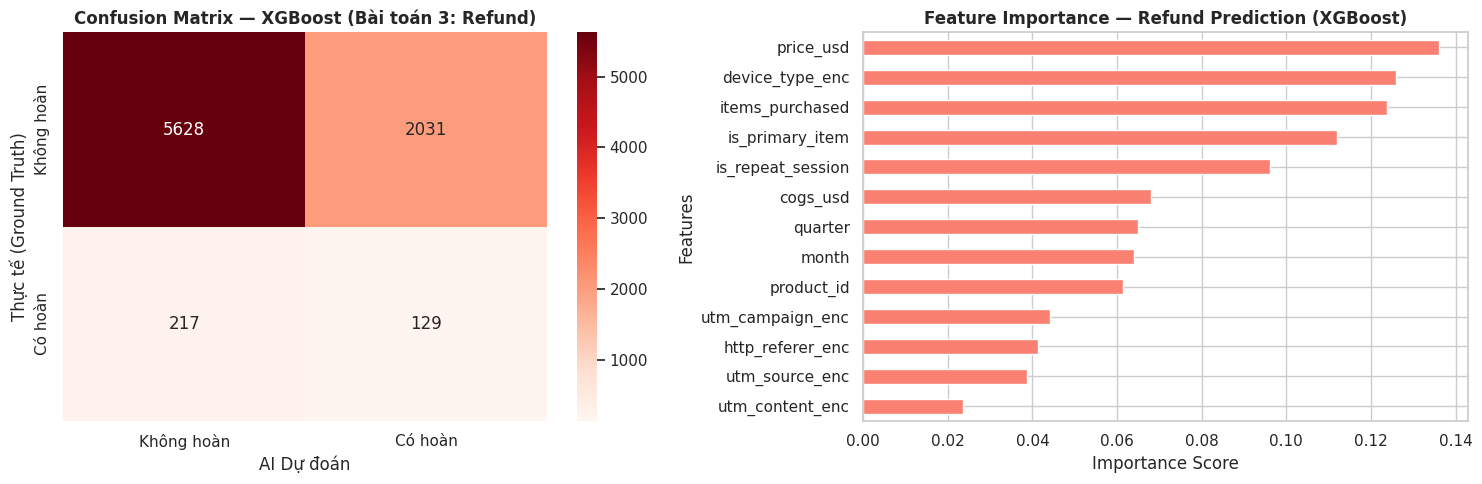


📝 BÁO CÁO CHI TIẾT HIỆU NĂNG PHÂN LOẠI (XGBOOST - BEST MODEL):
              precision    recall  f1-score   support

  Không hoàn     0.9629    0.7348    0.8335      7659
     Có hoàn     0.0597    0.3728    0.1030       346

    accuracy                         0.7192      8005
   macro avg     0.5113    0.5538    0.4682      8005
weighted avg     0.9238    0.7192    0.8020      8005

✅ XUẤT MÔ HÌNH THÀNH CÔNG: ./saved_models/bt3_refund_prediction_xgb.pkl


In [ ]:
# ============================================================
# VISUALIZE CỘT NGANG CHUẨN CHUYÊN GIA + LƯU MODEL
# ============================================================
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import joblib

best_ref = xgb_ref # Gán mô hình tốt nhất

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Vẽ Ma trận nhầm lẫn (Confusion Matrix)
y_pred_ref_best = best_ref.predict(X_ref_test.astype(float))
cm_ref = confusion_matrix(y_ref_test, y_pred_ref_best)
sns.heatmap(cm_ref, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Không hoàn', 'Có hoàn'],
            yticklabels=['Không hoàn', 'Có hoàn'])
axes[0].set_title('Confusion Matrix — XGBoost (Bài toán 3: Refund)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Thực tế (Ground Truth)')
axes[0].set_xlabel('AI Dự đoán')

# 🌟 Chuyển sang đồ thị thanh ngang (Horizontal Bar) giúp hiển thị trọn vẹn tên Đặc trưng
feat_imp_ref = pd.Series(best_ref.feature_importances_, index=REF_FEATURES).sort_values(ascending=True)
feat_imp_ref.plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Feature Importance — Refund Prediction (XGBoost)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].set_ylabel('Features')

plt.tight_layout()

# Lưu đồ thị báo cáo hệ thống
REPORT_DIR = './ml/reports/'
os.makedirs(REPORT_DIR, exist_ok=True)
plt.savefig(f'{REPORT_DIR}bt3_refund_results.png', dpi=150)
plt.show()

# 3. In bảng báo cáo chi tiết hiệu năng thuật toán
print("\n📝 BÁO CÁO CHI TIẾT HIỆU NĂNG PHÂN LOẠI (XGBOOST - BEST MODEL):")
print(classification_report(y_ref_test, y_pred_ref_best, target_names=['Không hoàn', 'Có hoàn'], digits=4))

# 4. Lưu mô hình
MODEL_DIR = './saved_models/'
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(best_ref, MODEL_DIR + 'bt3_refund_prediction_xgb.pkl')
print(f'✅ XUẤT MÔ HÌNH THÀNH CÔNG: {MODEL_DIR}bt3_refund_prediction_xgb.pkl')

In [ ]:
# ============================================================
# BÀI TOÁN 4: PHÂN CỤM KHÁCH HÀNG
# ============================================================
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans

print('=' * 60)
print('🚀 TIẾN HÀNH PHÂN CỤM RFM ĐÃ SỬA LỖI LOGIC VÀ CHỐNG OUTLIERS')
print('=' * 60)

# Đồng bộ mốc thời gian tối đa
df_feat['created_at'] = pd.to_datetime(df_feat['created_at'])
ref_date_all = df_feat['created_at'].max() + pd.Timedelta(days=1)

# SỬA LỖI LOGIC FREQUENCY: Tính toán tần suất chuẩn dựa trên số đơn hàng (orders) thực tế
rfm = df_feat.groupby('user_id').agg(
    Recency  =('created_at', lambda x: (ref_date_all - x.max()).days),
    Frequency=('order_id',   lambda x: x.dropna().nunique()), # Đếm số lượng hóa đơn duy nhất (Unique Invoice)
    Monetary =('revenue',    'sum')                           # Tổng giá trị chi tiêu tích lũy
).reset_index()

rfm['Monetary'] = rfm['Monetary'].fillna(0)

# RobustScaler dùng để xử lý triệt để phân phối Skewed của Monetary
scaler_rfm = RobustScaler()
X_rfm_scaled = scaler_rfm.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Gom cụm K-Means với K=4 phân khúc chiến lược
K_OPTIMAL = 4
km_rfm = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=15, max_iter=300)
rfm['cluster'] = km_rfm.fit_predict(X_rfm_scaled)

# Tự động ánh xạ phân cụm thông minh dựa trên doanh thu chi tiêu giảm dần
avg_monetary = rfm.groupby('cluster')['Monetary'].mean().sort_values(ascending=False).index.tolist()
segment_mapping = {
    avg_monetary[0]: "0=Premium (VIP Khách lớn)",
    avg_monetary[1]: "1=Regular (Thành viên tích cực)",
    avg_monetary[2]: "2=At-Risk (Nguy cơ rời bỏ)",
    avg_monetary[3]: "3=Churned (Đã rời đi)"
}
rfm['segment'] = rfm['cluster'].map(segment_mapping)

print("\n👥 BẢNG PROFILES KHÁCH HÀNG CHUẨN HÓA TOÁN HỌC (ROBUST RFM):")
cluster_profile = rfm.groupby('segment').agg(
    n_customers   = ('user_id', 'count'),
    mean_recency  = ('Recency', 'mean'),
    mean_frequency= ('Frequency', 'mean'),
    mean_monetary = ('Monetary', 'mean')
).round(2)
display(cluster_profile)

joblib.dump(km_rfm, MODEL_DIR + 'cluster_kmeans.pkl')
joblib.dump(scaler_rfm, MODEL_DIR + 'cluster_scaler.pkl')

print(f'\n✅ ĐÃ XUẤT MÔ HÌNH VẬT LÝ AN TOÀN LÊN HỆ THỐNG:')
print(f'  • {MODEL_DIR}cluster_kmeans.pkl (Chạy thuật toán trên Robust Scale)')
print(f'  • {MODEL_DIR}cluster_scaler.pkl')
print('=' * 60)

🚀 TIẾN HÀNH PHÂN CỤM RFM ĐÃ SỬA LỖI LOGIC VÀ CHỐNG OUTLIERS

👥 BẢNG PROFILES KHÁCH HÀNG CHUẨN HÓA TOÁN HỌC (ROBUST RFM):


,n_customers,mean_recency,mean_frequency,mean_monetary
segment,,,,
0=Premium (VIP Khách lớn),1406,209.65,1.23,116.05
1=Regular (Thành viên tích cực),6205,178.78,1.03,86.01
2=At-Risk (Nguy cơ rời bỏ),23283,386.60,1.00,50.82
3=Churned (Đã rời đi),363054,398.36,0.00,0.00



✅ ĐÃ XUẤT MÔ HÌNH VẬT LÝ AN TOÀN LÊN HỆ THỐNG:
  • ./saved_models/cluster_kmeans.pkl (Chạy thuật toán trên Robust Scale)
  • ./saved_models/cluster_scaler.pkl


In [ ]:
# ============================================================
# 5. SUMMARY DASHBOARD
# ============================================================
print('=' * 60)
print('📊 TỔNG HỢP KẾT QUẢ CÁC BÀI TOÁN ML')
print('=' * 60)

print('\n🔵 Bài toán 1: Dự đoán mua hàng (Binary Classification)')
display(df_clf_results)

print('\n🟠 Bài toán 2: Dự đoán doanh thu (Regression)')
display(df_reg_results)

print('\n🔴 Bài toán 3: Dự đoán hoàn tiền (Binary Classification)')
display(df_ref_results)

print('\n🟢 Bài toán 4 (Bonus): Phân cụm K-Means')
display(cluster_profile)

print('\n📁 Models đã lưu:')
for f in os.listdir(MODEL_DIR):
    print(f'  {MODEL_DIR}{f}')

📊 TỔNG HỢP KẾT QUẢ CÁC BÀI TOÁN ML

🔵 Bài toán 1: Dự đoán mua hàng (Binary Classification)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.3696,0.0853,0.8488,0.1550,0.6078
1,Decision Tree,0.3776,0.0852,0.8354,0.1546,0.6060
2,Random Forest (Best),0.4357,0.0854,0.7501,0.1534,0.6035
3,XGBoost,0.5584,0.0855,0.5650,0.1485,0.5989
4,LightGBM,0.6594,0.0844,0.4060,0.1397,0.5919



🟠 Bài toán 2: Dự đoán doanh thu (Regression)


,Model,MAE,RMSE,R2
2,RandomForest,12.1417,17.0818,0.0766
0,Ridge Regression,12.4155,17.1784,0.0691
1,DecisionTree,12.1778,17.1474,0.0675
3,XGBoost,12.2460,17.2313,0.0570



🔴 Bài toán 3: Dự đoán hoàn tiền (Binary Classification)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
Hạng,,,,,,
1,Random Forest,0.6937,0.0594,0.4104,0.1038,0.6064
2,XGBoost,0.7192,0.0597,0.3728,0.1030,0.6005
3,Logistic Regression,0.4150,0.0513,0.7168,0.0958,0.5742



🟢 Bài toán 4 (Bonus): Phân cụm K-Means


,n_customers,mean_recency,mean_frequency,mean_monetary
segment,,,,
0=Premium (VIP Khách lớn),1406,209.65,1.23,116.05
1=Regular (Thành viên tích cực),6205,178.78,1.03,86.01
2=At-Risk (Nguy cơ rời bỏ),23283,386.60,1.00,50.82
3=Churned (Đã rời đi),363054,398.36,0.00,0.00



📁 Models đã lưu:
  ./saved_models/clf_RF_tuned.pkl
  ./saved_models/clf_scaler.pkl
  ./saved_models/bt3_refund_prediction_xgb.pkl
  ./saved_models/cluster_scaler.pkl
  ./saved_models/cluster_kmeans.pkl
  ./saved_models/reg_1_RandomForest.pkl
  ./saved_models/bt2_revenue_prediction_xgb.pkl
  ./saved_models/bt1_purchase_prediction_xgb.pkl
  ./saved_models/label_encoders.pkl
